## Importing btrack and loading example datasets

In [1]:
import btrack

from btrack import datasets

We can automatically download some example data to play with:

In [2]:
CONFIG_FILE = datasets.cell_config()
# SEGMENTATION_FILE = datasets.example_segmentation_file()
# OBJECTS_FILE = datasets.example_track_objects_file()

## Finding objects to track

### Use case 1 - Objects from segmentation

These could be objects found using algorithms such as a UNet, *CellPose* or *StarDist*. We can use `scikit-image` to load the segmentation data, which returns a numpy array of dimensions (T, Y, X).

In [3]:
import matplotlib.pyplot as plt
from skimage.io import imread
from skimage.util import montage

In [ ]:
original_imgs

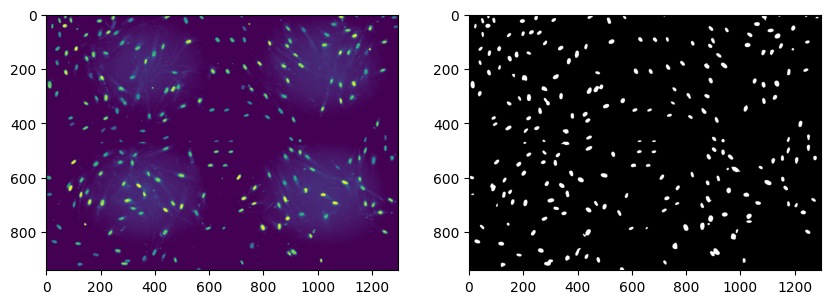

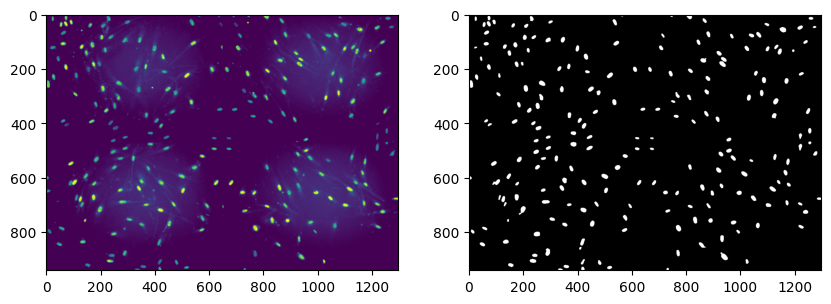

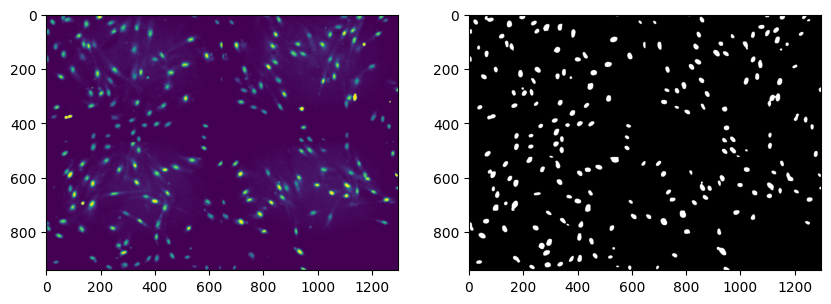

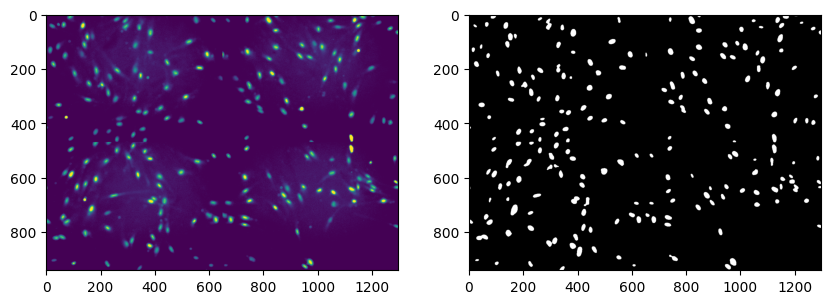

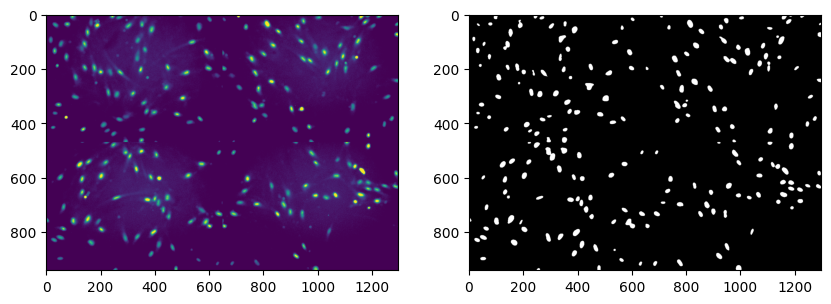

In [4]:
# Reload tifffiles back
from matplotlib.colors import ListedColormap
import matplotlib.pyplot as plt
import numpy as np
from skimage import io

basepath = '/nfs/turbo/umms-indikar/Ram/development/projects/reprogramming/Hybrid-Reprogramming/data/imaging'
sample = 'Myod_PRRX1'
sample_id = 1
f_start = 21
f_end = 32
channel = 'cy5'
# num_frames = 30

cmap = ListedColormap(['black', 'white'])

original_imgs = [
    io.imread(f'{basepath}/original_images/{channel}/{sample}_{sample_id}_frame_{t:03d}.tif')
    for t in range(f_start, f_end)
]

segmentation_masks = [
    io.imread(f'{basepath}/segmentation_masks/{channel}/{sample}_{sample_id}_frame_{t:03d}.tif')
    for t in range(f_start, f_end)
]

# Convert to numpy arrays
originals = np.stack(original_imgs)
segmentations = np.stack(segmentation_masks)


for i in range(5):
    img = originals[i]
    mask = segmentations[i]
    full_mask = mask.copy()
    mask[mask > 1] = 1
    
    # print(mask)
    # print(mask.min(), mask.max())
    fig, ax = plt.subplots(1, 2, figsize=(10, 10))
    ax1, ax2 = ax
    ax1.imshow(img)
    ax2.imshow(mask, cmap = cmap)

In [11]:
# # Reload tifffiles back
# import matplotlib.pyplot as plt
# import numpy as np
# from skimage import io


# # num_frames = 66
# num_frames = 60
# # num_frames = 30

# original_cy5_imgs = [
#     io.imread(f'mosaic_tiffs/original/{t}_cy5.tif')
#     for t in range(1, num_frames)
# ]

# original_mkate_imgs = [
#     io.imread(f'mosaic_tiffs/original/{t}_mkate.tif')
#     for t in range(1, num_frames)
# ]

# cy5_segmentation_masks = [
#     io.imread(f'mosaic_tiffs/segmentation/{t}_cy5.tif')
#     for t in range(1, num_frames)
# ]

# graphs = [
#     io.imread(f'mosaic_graphs/{t}.png')
#     for t in range(1, num_frames)
# ]

# imagexshape, imageyshape = original_cy5_imgs[0].shape

# graphr = [
#     io.imread(f'mosaic_graphs/{t}.png')[::, ::, :1].reshape(500, 1000)
#     for t in range(1, num_frames)
# ]
# graphg = [
#     io.imread(f'mosaic_graphs/{t}.png')[::, ::, 1:2].reshape(500, 1000)
#     for t in range(1, num_frames)
# ]
# graphb = [
#     io.imread(f'mosaic_graphs/{t}.png')[::, ::, 2:3].reshape(500, 1000)
#     for t in range(1, num_frames)
# ]

# graph_stack = np.zeros((num_frames, imagexshape+500, imageyshape+1000))  # 10 time points

# offset_x = imagexshape + 300
# offset_y = int(imageyshape//4.5)

# stack_with_image_r = np.zeros_like(graph_stack)
# stack_with_image_g = np.zeros_like(graph_stack)
# stack_with_image_b = np.zeros_like(graph_stack)

# for i in range(num_frames-1):
#     stack_with_image_r[i, offset_y:offset_y+500, offset_x:offset_x+1000] = image_to_add = graphr[i]
#     stack_with_image_g[i, offset_y:offset_y+500, offset_x:offset_x+1000] = image_to_add = graphg[i]
#     stack_with_image_b[i, offset_y:offset_y+500, offset_x:offset_x+1000] = image_to_add = graphb[i]


# # Convert to numpy arrays
# original_imgs = np.stack(original_cy5_imgs)
# # original_imgs = np.stack(original_mkate_imgs)
# segmentation_masks = np.stack(cy5_segmentation_masks)

# segmentation = segmentation_masks

# # for i in range(num_frames):
# #     img = original_cy5_imgs[i]
# #     mask = cy5_segmentation_masks[i]
# #     fig, ax = plt.subplots(figsize=(10, 10))
# #     ax.imshow(img)

In [12]:
# original_cy5_imgs[0].shape
# segmentation_masks.shape
# segmentation = segmentation_masks

In [21]:
segmentation_masks

[array([[  0,   0,   0, ...,   0,   0,   0],
        [  0,   0,   0, ...,   0,   0,   0],
        [  0,   0,   0, ...,   0,   0,   0],
        ...,
        [449, 449, 449, ...,   0,   0,   0],
        [449, 449, 449, ...,   0,   0,   0],
        [449, 449, 449, ...,   0,   0,   0]],
       shape=(942, 1298), dtype=uint16),
 array([[  0,   0,   0, ...,   0,   0,   0],
        [  0,   0,   0, ...,   0,   0,   0],
        [  0,   0,   0, ...,   0,   0,   0],
        ...,
        [482, 482, 482, ...,   0,   0,   0],
        [482, 482, 482, ...,   0,   0,   0],
        [482,   0,   0, ...,   0,   0,   0]],
       shape=(942, 1298), dtype=uint16),
 array([[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]], shape=(942, 1298), dtype=uint16),
 array([[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
     

### show the segmentation as a montage

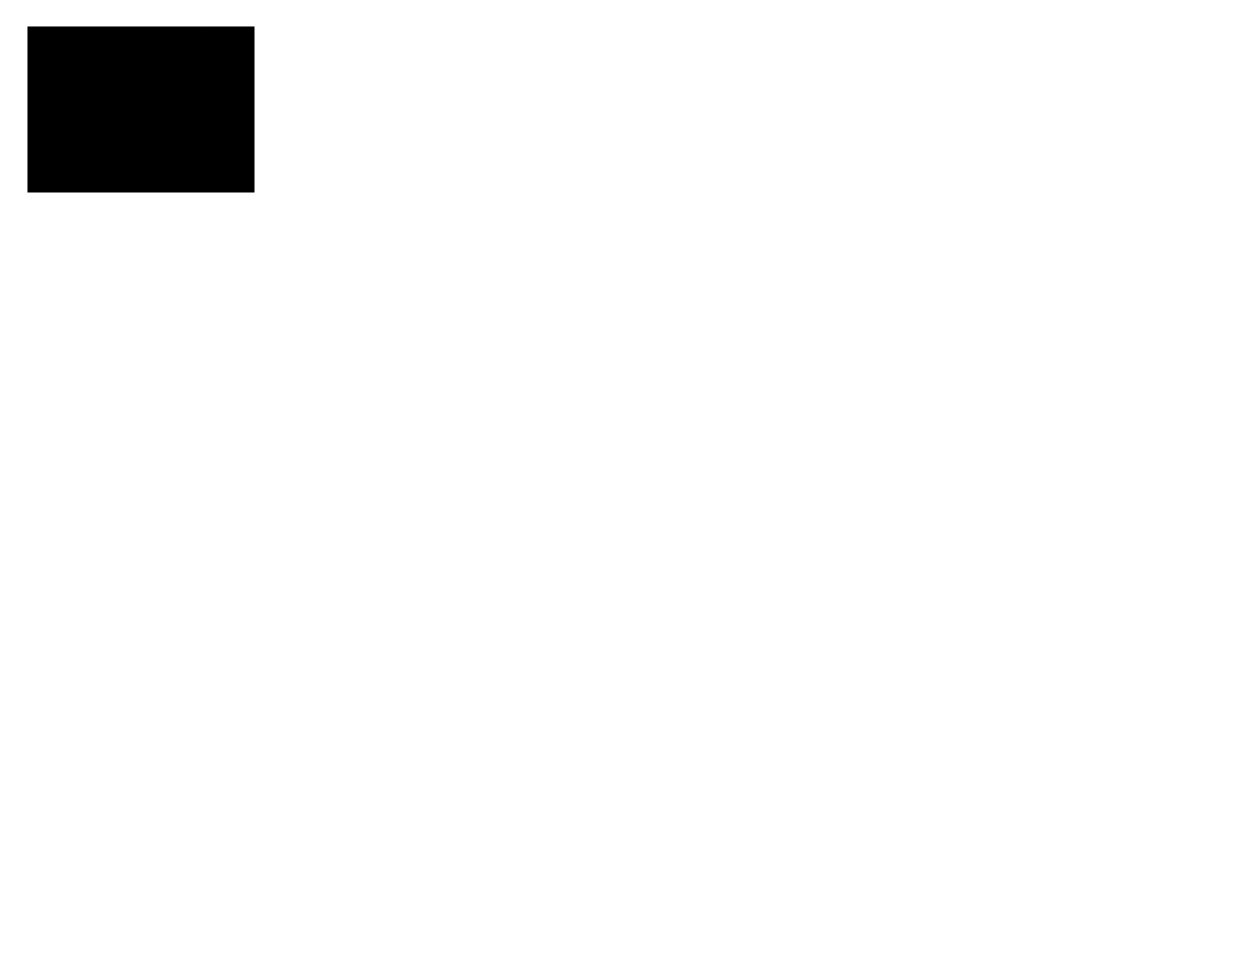

In [22]:
seq = montage(
    segmentations[::20, ::10, ::10], 
    grid_shape=(5, 5), 
    padding_width=10, 
    fill=255,
)

fig, ax = plt.subplots(1, figsize=(16, 16))
ax.imshow(seq, cmap=plt.cm.gray)
ax.axis(False)
plt.show()

### localize the objects

Now we use a utility function to localise the objects in the segmentation. Note that we can also use scikit-image `regionprops` to calculate properties for each object, using the `properties` keyword:

In [23]:
FEATURES = [
    "area", 
    "major_axis_length", 
    "minor_axis_length", 
    "orientation", 
    "solidity",
    "eccentricity"
]

objects = btrack.utils.segmentation_to_objects(
    segmentations, 
    properties=tuple(FEATURES), 
    num_workers=16,  # parallelise this
)

[INFO][2025/07/30 11:11:08 AM] Localizing objects from segmentation...
[INFO][2025/07/30 11:11:08 AM] Processing using 16 workers.
100%|██████████| 10/10 [00:00<00:00, 27.35it/s]
[INFO][2025/07/30 11:11:09 AM] Objects are of type: <class 'dict'>
[INFO][2025/07/30 11:11:09 AM] ...Found 3657 objects in 10 frames.


We can also inspect each returned object to determine it's properties:

In [24]:
# objects_list = list(objects)
# objects_list = eval(str(objects_list))

In [25]:
getattr(objects[2300], 'ID')

2300

In [26]:
# import pandas as pd
# import numpy as np

# def clean_numpy_dict_list(dict_list):
#     cleaned = []
#     for d in dict_list:
#         clean_dict = {}
#         for key, val in d.items():
#             if isinstance(val, np.generic):
#                 # Convert numpy scalar types
#                 clean_dict[key] = val.item()
#             elif isinstance(val, np.ndarray):
#                 # Flatten arrays into string
#                 clean_dict[key] = ','.join(map(str, val.flatten()))
#             else:
#                 clean_dict[key] = val
#         cleaned.append(clean_dict)
#     return cleaned

# def save_dict_list_to_csv(dict_list, filename):
#     cleaned = clean_numpy_dict_list(dict_list)
#     df = pd.DataFrame(cleaned)
#     df.to_csv(filename, index=False)
#     print(f"Saved to {filename}")

# save_dict_list_to_csv(objects_list, "data/tracked_objects.csv")

In [27]:
# import pandas as pd

# import pandas as pd

# # Feature names in the order they appear in obj.features
# FEATURE_NAMES = [
#     'dummy',
#     'states',
#     'label',
#     'area',
#     'major_axis_length',
#     'minor_axis_length',
#     'orientation',
#     'solidity',
#     'eccentricity'
# ]

# def save_objects_with_named_features(objects, output_csv_path):
#     rows = []

#     for obj in objects:
#         row = {
#             'ID': getattr(obj, 'ID', None),
#             't': getattr(obj, 't', None),
#             'x': getattr(obj, 'x', None),
#             'y': getattr(obj, 'y', None),
#             'z': getattr(obj, 'z', 0.0),
#         }
        
#         for i, name in enumerate(FEATURE_NAMES):
#             row[name] = getattr(obj, name, None)

#         rows.append(row)

#     df = pd.DataFrame(rows)
#     df.to_csv(output_csv_path, index=False)
#     print(f"Saved {len(df)} objects with named features to {output_csv_path}")

# save_objects_with_named_features(objects, "data/tracked_objects.csv")

In [28]:
btrack.SystemInformation()

btrack_version: 0.6.5
system_platform: Linux-4.18.0-553.50.1.el8_10.x86_64-x86_64-with-glibc2.28
system_python: 3.12.9

## Run Tracking

In [ ]:
# initialise a tracker session using a context manager
with btrack.BayesianTracker() as tracker:

    # configure the tracker using a config file
    tracker.configure(CONFIG_FILE)
    tracker.max_search_radius = 50
    tracker.tracking_updates = ["MOTION", "VISUAL"]
    tracker.features = FEATURES

    # append the objects to be tracked
    tracker.append(objects)

    # set the tracking volume
    tracker.volume=((0, 1600), (0, 1200))

    # track them (in interactive mode)
    tracker.track(step_size=100)

    # generate hypotheses and run the global optimizer
    tracker.optimize()

    # get the tracks in a format for napari visualization
    data, properties, graph = tracker.to_napari()
    
    # store the tracks
    tracks = tracker.tracks
    
    # store the configuration
    cfg = tracker.configuration


    # export the track data 
    tracker.export(f"tracks_{f_start}_{f_end}.h5", obj_type="obj_type_1")
    

[INFO][2025/07/30 11:11:43 AM] Loaded btrack: /home/nuvi/.local/lib/python3.12/site-packages/btrack/libs/libtracker.so
[INFO][2025/07/30 11:11:43 AM] Starting BayesianTracker session
[INFO][2025/07/30 11:11:43 AM] Loading configuration file: /home/nuvi/.cache/btrack-examples/examples/cell_config.json
[INFO][2025/07/30 11:11:43 AM] Objects are of type: <class 'list'>
[INFO][2025/07/30 11:11:43 AM] Starting tracking... 
[INFO][2025/07/30 11:11:43 AM] Update using: ['VISUAL', 'MOTION']
[INFO][2025/07/30 11:11:43 AM] Tracking objects in frames 0 to 10 (of 10)...
[INFO][2025/07/30 11:11:46 AM]  - Timing (Bayesian updates: 235.72ms, Linking: 5.47ms)
[INFO][2025/07/30 11:11:46 AM]  - Probabilities (Link: 0.55522, Lost: 1.00000)
[INFO][2025/07/30 11:11:46 AM] SUCCESS.
[INFO][2025/07/30 11:11:46 AM]  - Found 1515 tracks in 10 frames (in 0.0s)
[INFO][2025/07/30 11:11:46 AM]  - Inserted 915 dummy objects to fill tracking gaps
[INFO][2025/07/30 11:11:46 AM] Loading hypothesis model: cell_hypothesi

In [50]:
# df = btrack.utils.tracks.to_pandas(tracker.tracks)
# csv_path = os.path.join(OUTPUT_FOLDER, f"tracks_chunk_{f_start}_{f_end}.csv")
# df.to_csv(csv_path, index=False)
# print(f"Saved chunk {chunk_index} to {csv_path}")

In [51]:
# import pandas as pd

# def tracks_to_dataframe(tracks):
#     data = []
#     for track in tracks:
#         for detection in track:
#             data.append({
#                 'track_id': track.ID,
#                 't': detection.t,
#                 'x': detection.x,
#                 'y': detection.y,
#                 'z': detection.z if hasattr(detection, 'z') else 0,
#                 'area': detection.area,  # or proper index
#                 'solidity': detection.solidity,
#                 'major_axis_length': detection.major_axis_length,
#                 'orientation': orientation,
#                 'parent': detection.parent,
#                 'root': detection.root,
                
#             })

#     return pd.DataFrame(data)

# df = tracks_to_dataframe(tracker.tracks)


In [52]:
# import glob
# df_all = pd.concat([pd.read_csv(f) for f in sorted(glob.glob("btrack_chunks/*.csv"))], ignore_index=True)
# df_all.to_csv("combined_tracks.csv", index=False)


In [ ]:
import btrack
import pandas as pd
import os
from collections import defaultdict

# CONFIG_FILE = 'path/to/btrack_config.json'
FEATURES = ['area', 'eccentricity']  # set this based on your data
MAX_SEARCH_RADIUS = 50
CHUNK_SIZE = 10
OVERLAP = 0

OUTPUT_FOLDER = "data/btrack_chunks"
os.makedirs(OUTPUT_FOLDER, exist_ok=True)

# Group objects by frame
objects_by_frame = defaultdict(list)
for obj in objects:
    objects_by_frame[obj.t].append(obj)

# Sort frames
sorted_frames = sorted(objects_by_frame.keys())
num_frames = len(sorted_frames)

def run_btrack_on_chunk(chunk_objects, chunk_index):
    with btrack.BayesianTracker() as tracker:
        tracker.configure(CONFIG_FILE)
        
    
        tracker.configure(CONFIG_FILE)
        tracker.max_search_radius = MAX_SEARCH_RADIUS
        tracker.tracking_updates = ["MOTION", "VISUAL"]
        tracker.features = FEATURES
        
        # set the tracking volume
        tracker.volume=((0, 1600), (0, 1200))

        tracker.append(chunk_objects)
        tracker.track(step_size=100)
        tracker.optimize()

        df = btrack.utils.tracks.to_pandas(tracker.tracks)
        csv_path = os.path.join(OUTPUT_FOLDER, f"tracks_chunk_{chunk_index:02d}.csv")
        df.to_csv(csv_path, index=False)
        print(f"Saved chunk {chunk_index} to {csv_path}")

# Track in chunks
start_idx = 0
chunk_index = 0

while start_idx < num_frames:
    end_idx = min(start_idx + CHUNK_SIZE, num_frames)
    frames_in_chunk = sorted_frames[start_idx:end_idx]

    # Flatten the objects for this chunk
    chunk_objects = []
    for t in frames_in_chunk:
        chunk_objects.extend(objects_by_frame[t])

    run_btrack_on_chunk(chunk_objects, chunk_index)

    # Advance
    start_idx = end_idx - OVERLAP
    chunk_index += 1


[INFO][2025/07/30 09:54:01 AM] Loaded btrack: /home/nuvi/.local/lib/python3.12/site-packages/btrack/libs/libtracker.so
[INFO][2025/07/30 09:54:01 AM] Starting BayesianTracker session
[INFO][2025/07/30 09:54:01 AM] Loading configuration file: /home/nuvi/.cache/btrack-examples/examples/cell_config.json
[INFO][2025/07/30 09:54:01 AM] Loading configuration file: /home/nuvi/.cache/btrack-examples/examples/cell_config.json
[INFO][2025/07/30 09:54:01 AM] Objects are of type: <class 'list'>
[INFO][2025/07/30 09:54:01 AM] Starting tracking... 
[INFO][2025/07/30 09:54:01 AM] Update using: ['MOTION', 'VISUAL']
[INFO][2025/07/30 09:54:01 AM] Tracking objects in frames 0 to 10 (of 10)...
[INFO][2025/07/30 09:54:02 AM]  - Timing (Bayesian updates: 144.43ms, Linking: 4.53ms)
[INFO][2025/07/30 09:54:02 AM]  - Probabilities (Link: 0.51430, Lost: 0.63440)
[INFO][2025/07/30 09:54:02 AM] SUCCESS.
[INFO][2025/07/30 09:54:02 AM]  - Found 1125 tracks in 10 frames (in 0.0s)
[INFO][2025/07/30 09:54:02 AM]  - I

In [ ]:
import glob

all_chunks = sorted(glob.glob("data/btrack_chunks/tracks_chunk_*.csv"))
df_all = pd.concat([pd.read_csv(f) for f in all_chunks], ignore_index=True)
df_all.to_csv("data/combined_tracks.csv", index=False)


## Inspecting the output

We can also inspect each returned track to determine it's properties:

In [22]:
len(tracks)

1119

In [19]:
tracks_bk = tracks

In [20]:
cell = tracks[1]

In [25]:
type(cell)

btrack.btypes.Tracklet

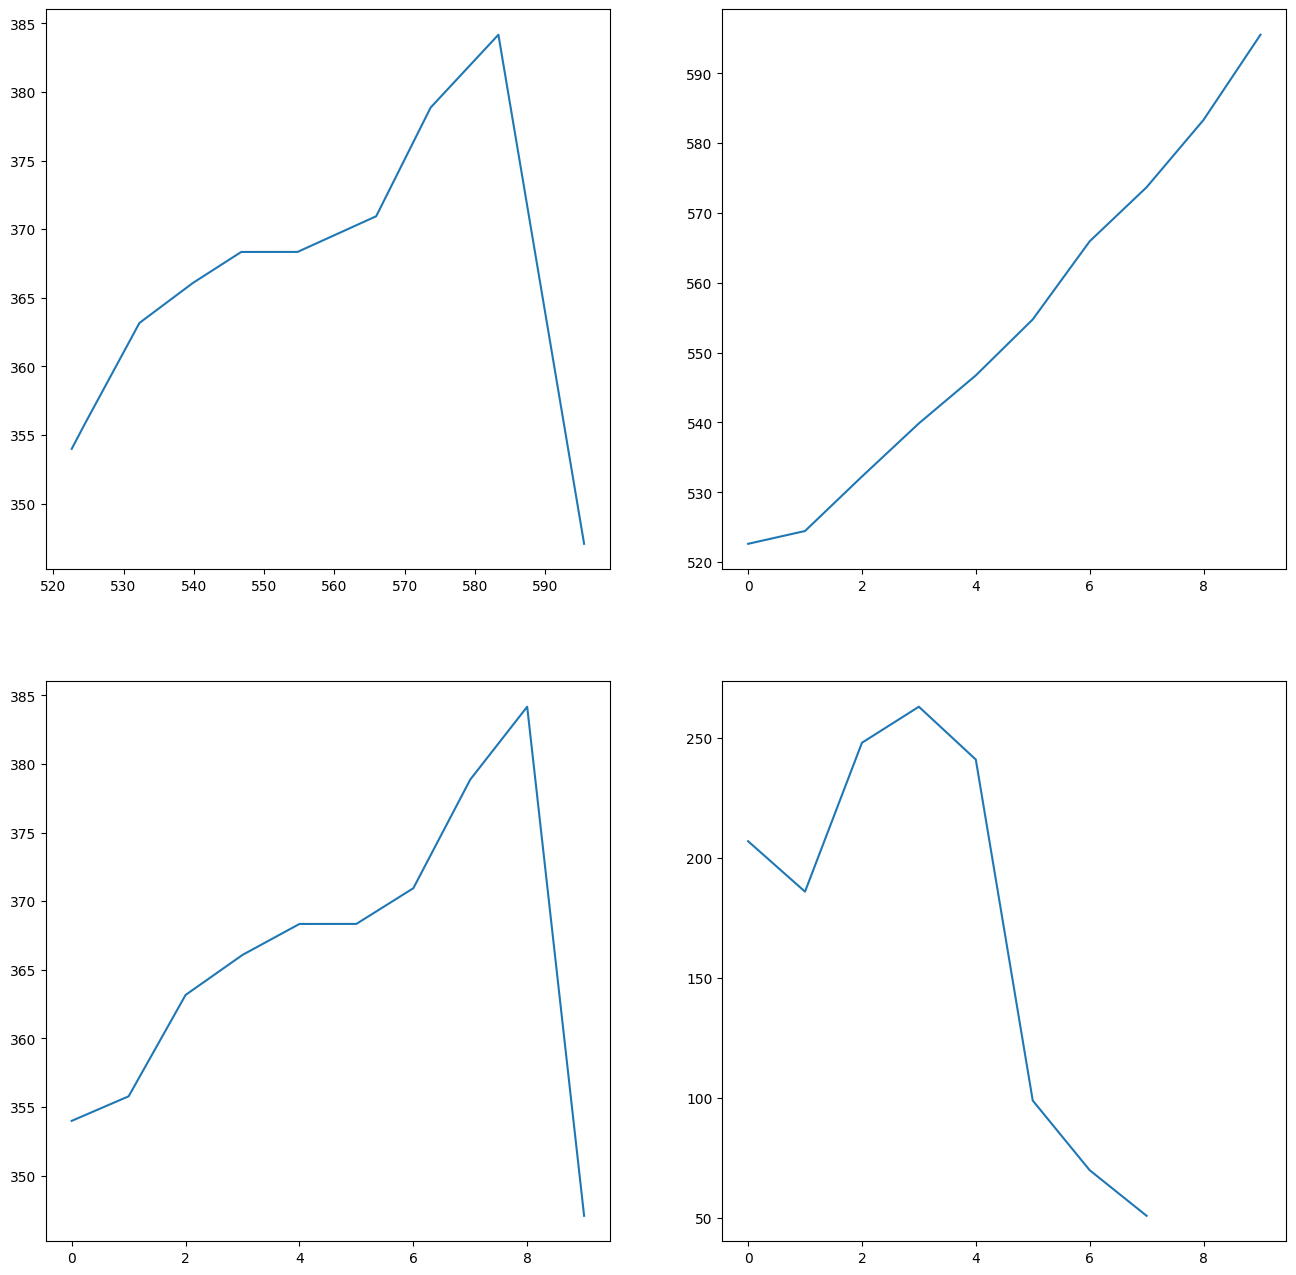

In [24]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 16))
ax1.plot(cell.x, cell.y)
ax2.plot(cell.t, cell.x)
ax3.plot(cell.t, cell.y)
ax4.plot(cell.t, cell["area"])
plt.show()

## Visualising the data with napari

Finally, we an inspect the entire tracking output using *napari*:

In [135]:
import napari


viewer = napari.Viewer()

viewer.add_image(
    segmentation, 
    name="Segmentation",
    opacity=0.3,
)

viewer.add_image(
    original_imgs, 
    name="Original Images",
    opacity=0.75,
)

# the track data from the tracker
viewer.add_tracks(
    data, 
    properties=properties, 
    graph=graph,
    name="Tracks", 
    blending="translucent",
    visible=True,
)

viewer.add_image(
    stack_with_image_r, 
    name="Graphr",
    colormap='red',
    opacity=0.7,
    blending='additive',
)
viewer.add_image(
    stack_with_image_g, 
    name="Graphg",
    colormap='green',
    opacity=0.7,
    blending='additive',
)
viewer.add_image(
    stack_with_image_b, 
    name="Graphb",
    colormap='blue',
    opacity=0.7,
    blending='additive',
)

napari.run()

Rendering frames...


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 60/60 [00:26<00:00,  2.25it/s]


In [ ]:
import napari


viewer = napari.Viewer()

viewer.add_image(
    segmentation, 
    name="Segmentation",
    opacity=0.5,
)

viewer.add_image(
    graphs, 
    name="PLOT",
    opacity=0.5,
)

# # the track data from the tracker
# viewer.add_tracks(
#     data, 
#     properties=properties, 
#     graph=graph,
#     name="Tracks", 
#     blending="translucent",
#     visible=True,
# )

napari.run()

In [33]:
# from napari.utils import nbscreenshot


# nbscreenshot(viewer)

In [54]:
import imageio

path_to_save_gif = 'gif.gif'

ims = [
    imageio.imread(f'mosaic_graphs/{t}.png')
    for t in range(num_frames)
]

imageio.mimwrite(path_to_save_gif, ims)

/var/folders/bw/k47pyks15hj5krd7g8r02s_c0000gn/T/ipykernel_90361/4144399679.py:6: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  imageio.imread(f'mosaic_graphs/{t}.png')


In [53]:
len(original_cy5_imgs)

59

In [34]:
# import sample data
from skimage.data import cells3d

import napari

# create a `Viewer` and `Image` layer here
viewer, image_layer = napari.imshow(cells3d())

# print shape of image data
print(image_layer.data.shape)

# start the event loop and show the viewer
napari.run()

(60, 2, 256, 256)


In [20]:
from skimage import data

import napari

viewer, image_layer = napari.imshow(data.astronaut(), rgb=True)

In [76]:
len(ims)

60

In [79]:
len(segmentation)

59